<a href="https://colab.research.google.com/github/tylerdore/tylerdore.github.io/blob/master/Tailings_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Package Install**

---



In [ ]:
# Install packages
!pip install openmeteo-requests requests-cache retry-requests

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.7/208.7 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 730.5/730.5 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.4/399.4 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 46.4 MB/s eta 0:00:00
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 25.12.19
    Uninstalling flatbuffers-25.12.19:
      Successfully uninstalled flatbuffers-25.12.19


# **Dataset Upload + Reading**

---



In [ ]:
file = "Cachuma_Lake_Dataset_Splits.xlsx"

# --- LOAD PRE-DEFINED SPLITS (DO NOT RECOMBINE) ---
train_df = pd.read_excel(file, sheet_name="Training Set (2000–2020)")
val_df   = pd.read_excel(file, sheet_name="Validation Set (2021–2022)")
test_df  = pd.read_excel(file, sheet_name="Test Set (2023–2026)")

# --- ENSURE TEMPORAL ORDER ---
train_df = train_df.sort_values(by="date").reset_index(drop=True)
val_df   = val_df.sort_values(by="date").reset_index(drop=True)
test_df  = test_df.sort_values(by="date").reset_index(drop=True)

# --- OPTIONAL: RECREATE EVENT GROUPS (WITHIN EACH SPLIT ONLY) ---
# This preserves temporal structure without leakage across splits
def add_event_groups(df):
    df = df.copy()
    df["event"] = (df["spill_binary"].diff() == 1).cumsum()
    return df

train_df = add_event_groups(train_df)
val_df   = add_event_groups(val_df)
test_df  = add_event_groups(test_df)

# --- DROP UNUSED COLUMNS ---
drop_cols = ["spillway_cfs", "date", "split", "event"]

train_df = train_df.drop(columns=drop_cols, errors="ignore")
val_df   = val_df.drop(columns=drop_cols, errors="ignore")
test_df  = test_df.drop(columns=drop_cols, errors="ignore")

# **OpenMeteo Current Precipitation Forecast**

---



In [ ]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://api.open-meteo.com/v1/forecast"
params = {
	"latitude": 34.591,
	"longitude": -119.995,
	"daily": "precipitation_sum",
	"precipitation_unit": "inch",
    "forecast_days": 7 # Request enough days to calculate 3-day and 7-day sums
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]


# Process daily data. The order of variables needs to be the same as requested.
daily = response.Daily()
daily_precipitation_sum = daily.Variables(0).ValuesAsNumpy()

daily_data = {"date": pd.date_range(
	start = pd.to_datetime(daily.Time(), unit = "s", utc = True),
	end =  pd.to_datetime(daily.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = daily.Interval()),
	inclusive = "left"
)}

daily_data["precipitation_sum"] = daily_precipitation_sum

daily_dataframe = pd.DataFrame(data = daily_data)

forecast_precip = daily_precipitation_sum[0]
precip_3day = daily_precipitation_sum[2] # Precipitation on the 3rd day
precip_7day = daily_precipitation_sum[6] # Precipitation on the 7th day


print("Forecast precip (in):", forecast_precip)
print("Forecast precip 3day (in):", precip_3day)
print("Forecast precip 7day (in):", precip_7day)


Forecast precip (in): 0.0
Forecast precip 3day (in): 0.24803151
Forecast precip 7day (in): 0.0


# **RISE Current (T-1) Reservoir Level**

---



In [ ]:
import requests, pandas as pd
from datetime import datetime, timedelta

# Dates for 2nd day ago and 1st day ago
d1, d2 = [(datetime.now() - timedelta(days=i)).strftime('%Y%m%d') for i in (2, 1)]

# --- Elevation ---
res = requests.get(f"https://data.usbr.gov/rise/api/result?itemId=10786&dateTime[after]={d1}&dateTime[strictly_before]={d2}", headers={"Accept": "application/vnd.api+json"}).json()
if res.get("data"):
    df = pd.DataFrame([{"date": r["attributes"]["dateTime"], "elev": r["attributes"]["result"]} for r in res["data"]])
    latest_elevation = df['elev'].iloc[-1]
    print(f"Retrieved {d1} Elevation: {latest_elevation} ft")
else:
    latest_elevation = 752.85
    print("No data; using fallback elevation.")

# --- Storage ---
res = requests.get(f"https://data.usbr.gov/rise/api/result?itemId=10787&dateTime[after]={d1}&dateTime[strictly_before]={d2}", headers={"Accept": "application/vnd.api+json"}).json()
if res.get("data"):
    df = pd.DataFrame([{"date": r["attributes"]["dateTime"], "storage": r["attributes"]["result"]} for r in res["data"]])
    latest_storage = df['storage'].iloc[-1]
    print(f"Retrieved {d1} Storage: {latest_storage} af")
else:
    latest_storage = 183500.0
    print("No data; using fallback storage.")

# --- Inflow ---
res = requests.get(f"https://data.usbr.gov/rise/api/result?itemId=10788&dateTime[after]={d1}&dateTime[strictly_before]={d2}", headers={"Accept": "application/vnd.api+json"}).json()
if res.get("data"):
    df = pd.DataFrame([{"date": r["attributes"]["dateTime"], "inflow": r["attributes"]["result"]} for r in res["data"]])
    latest_inflow = max(df['inflow'].iloc[-1], 0.0)
    print(f"Retrieved {d1} Inflow: {latest_inflow} cfs")
else:
    latest_inflow = 0.0
    print("No data; using fallback inflow.")

# --- Release Total ---
res = requests.get(f"https://data.usbr.gov/rise/api/result?itemId=10789&dateTime[after]={d1}&dateTime[strictly_before]={d2}", headers={"Accept": "application/vnd.api+json"}).json()
if res.get("data"):
    df = pd.DataFrame([{"date": r["attributes"]["dateTime"], "release_total": r["attributes"]["result"]} for r in res["data"]])
    latest_release_total = df['release_total'].iloc[-1]
    print(f"Retrieved {d1} Release Total: {latest_release_total} cfs")
else:
    latest_release_total = 0.0
    print("No data; using fallback release total.")

# --- Release Outlet ---
res = requests.get(f"https://data.usbr.gov/rise/api/result?itemId=10790&dateTime[after]={d1}&dateTime[strictly_before]={d2}", headers={"Accept": "application/vnd.api+json"}).json()
if res.get("data"):
    df = pd.DataFrame([{"date": r["attributes"]["dateTime"], "release_outlet": r["attributes"]["result"]} for r in res["data"]])
    latest_release_outlet = df['release_outlet'].iloc[-1]
    print(f"Retrieved {d1} Release Outlet: {latest_release_outlet} cfs")
else:
    latest_release_outlet = 0.0
    print("No data; using fallback release outlet.")

Retrieved 20260422 Elevation: 752.41 ft
Retrieved 20260422 Storage: 191472 af
Retrieved 20260422 Inflow: 97.7 cfs
Retrieved 20260422 Release Total: 212.1 cfs
Retrieved 20260422 Release Outlet: 0.42 cfs


# **Model Training**

---



In [ ]:
train_df["forecast_precip"] = forecast_precip
val_df["forecast_precip"] = forecast_precip
test_df["forecast_precip"] = forecast_precip

In [ ]:
def add_features(df):
    df = df.copy()

    # Rolling precipitation (memory effect)
    if "precip_in" in df.columns:
        df["precip_3day"] = df["precip_in"].rolling(3).sum()
        df["precip_7day"] = df["precip_in"].rolling(7).sum()

    # Fill NaNs from rolling
    df = df.fillna(0)

    return df

train_df = add_features(train_df)
val_df   = add_features(val_df)
test_df  = add_features(test_df)

In [ ]:
target = "spill_binary"

features = [col for col in train_df.columns if col not in [target]]

X_train = train_df[features]
y_train = train_df[target]

X_val = val_df[features]
y_val = val_df[target]

X_test = test_df[features]
y_test = test_df[target]

In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight={0:1, 1:10},
    random_state=42,
    n_jobs=-1
)

In [ ]:
model.fit(X_train, y_train)

RandomForestClassifier(class_weight={0: 1, 1: 10}, max_depth=4,
                       min_samples_leaf=10, min_samples_split=20,
                       n_estimators=500, n_jobs=-1, random_state=42)

In [ ]:
y_val_prob = model.predict_proba(X_val)[:, 1]



y_test_prob = model.predict_proba(X_test)[:, 1]

NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

# **Trained Model Evaluation**

---



In [ ]:
y_train_prob = model.predict_proba(X_train)[:, 1]

print("Train ROC AUC:", roc_auc_score(y_train, y_train_prob))
print("Validation ROC AUC:", roc_auc_score(y_val, y_val_prob))
print("Test ROC AUC:", roc_auc_score(y_test, y_test_prob))

Train ROC AUC: 0.999383412421285
Validation ROC AUC: 0.9348336524220641
Test ROC AUC: 0.9549092172867569


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

n_estimators_grid = [100, 200, 300, 500]
max_depth_grid = [4, 6, 8, 10, None]

results = []

best_score = -np.inf
best_params = None

for n in n_estimators_grid:
    for depth in max_depth_grid:
        model = RandomForestClassifier(
            n_estimators=n,
            max_depth=depth,
            min_samples_split=20,
            min_samples_leaf=10,
            class_weight={0:1, 1:10},
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_train, y_train)

        y_val_prob = model.predict_proba(X_val)[:, 1]
        val_auc = roc_auc_score(y_val, y_val_prob)

        results.append({
            "n_estimators": n,
            "max_depth": depth,
            "val_auc": val_auc
        })

        if val_auc > best_score:
            best_score = val_auc
            best_params = (n, depth)

print("Best Params:", best_params)
print("Best Validation AUC:", best_score)

Best Params: (500, 4)
Best Validation AUC: 0.9348336524220641


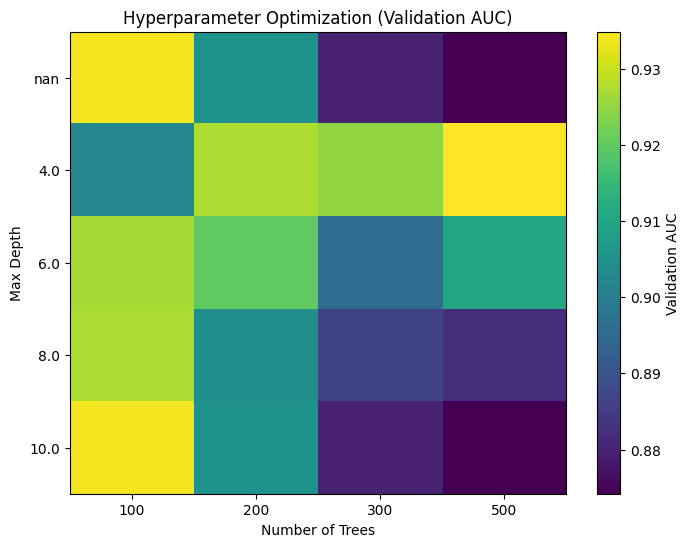

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Pivot for heatmap
pivot = results_df.pivot(index="max_depth", columns="n_estimators", values="val_auc")

# Plot
plt.figure(figsize=(8,6))
im = plt.imshow(pivot, aspect='auto')

plt.colorbar(im, label="Validation AUC")

plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)

plt.xlabel("Number of Trees")
plt.ylabel("Max Depth")
plt.title("Hyperparameter Optimization (Validation AUC)")

plt.show()

Optimal threshold: 0.1


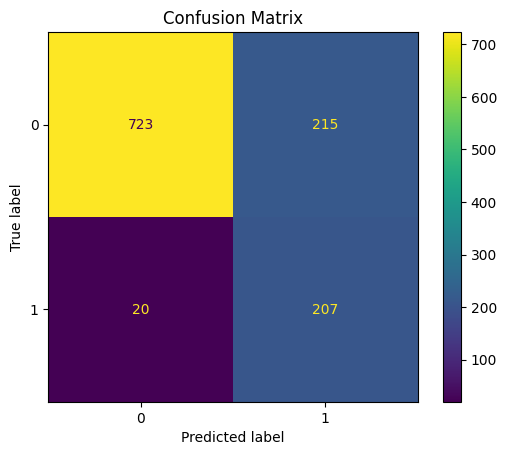

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.metrics import f1_score

thresholds = np.linspace(0.1, 0.9, 50)
best_t = 0
best_f1 = 0

for t in thresholds:
    preds = (y_val_prob >= t).astype(int)
    f1 = f1_score(y_val, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

threshold = best_t
print("Optimal threshold:", threshold)
y_test_pred = (y_test_prob > threshold).astype(int)

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

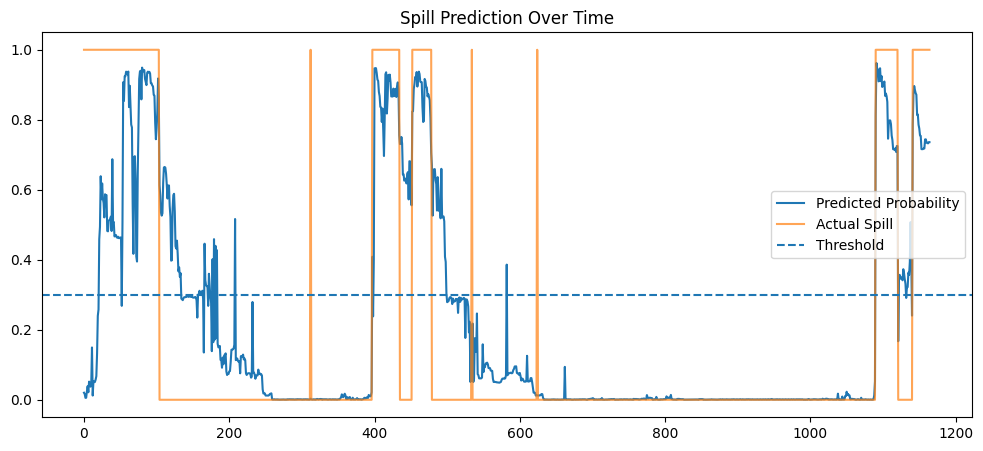

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(y_test_prob, label="Predicted Probability")
plt.plot(y_test.values, label="Actual Spill", alpha=0.7)

plt.axhline(0.3, linestyle="--", label="Threshold")

plt.legend()
plt.title("Spill Prediction Over Time")
plt.show()

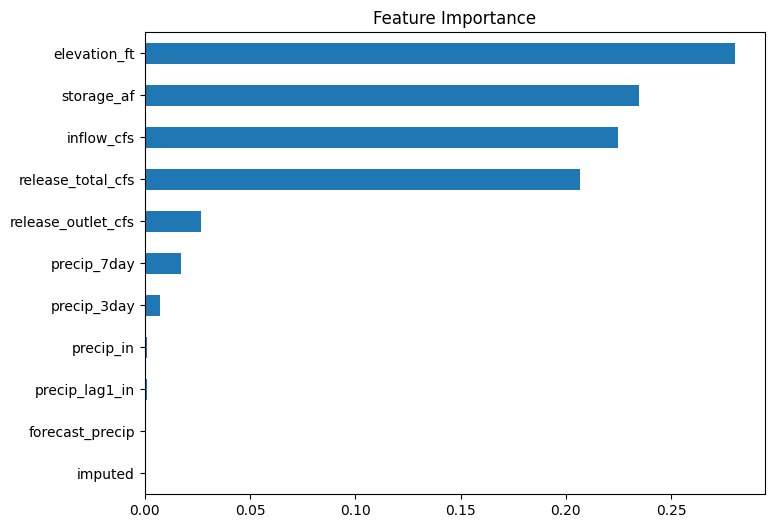

In [ ]:
importance = pd.Series(model.feature_importances_, index=features)
importance = importance.sort_values()

importance.plot(kind="barh", figsize=(8,6))
plt.title("Feature Importance")
plt.show()

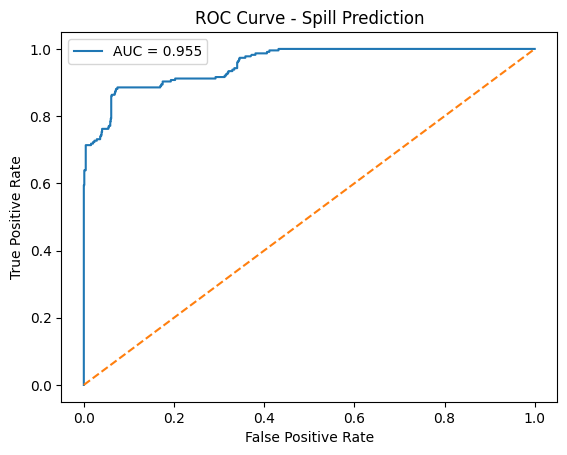

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_test_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Spill Prediction")
plt.legend()
plt.show()

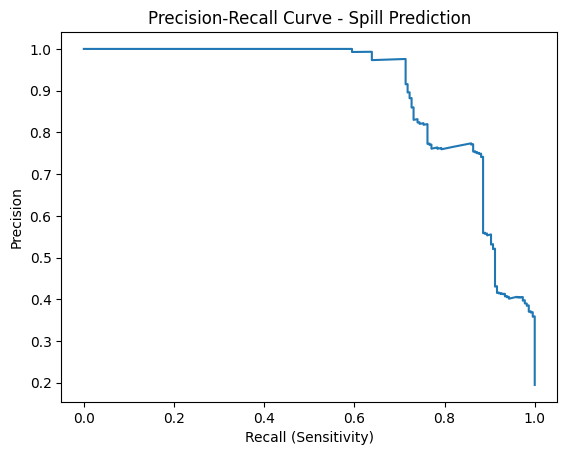

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_test_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Spill Prediction")
plt.show()

# **Model Validation**

---



In [ ]:
print(np.percentile(y_test_prob, [0, 25, 50, 75, 100]))

[1.46055449e-04 8.58462273e-04 1.20290007e-02 3.31187226e-01
 9.62238479e-01]


In [ ]:
y_val_prob
y_test_prob

array([0.02013161, 0.01634188, 0.0054534 , ..., 0.73245588, 0.73602549,
       0.73611368])

In [ ]:
y_train_prob = model.predict_proba(X_train)[:, 1]

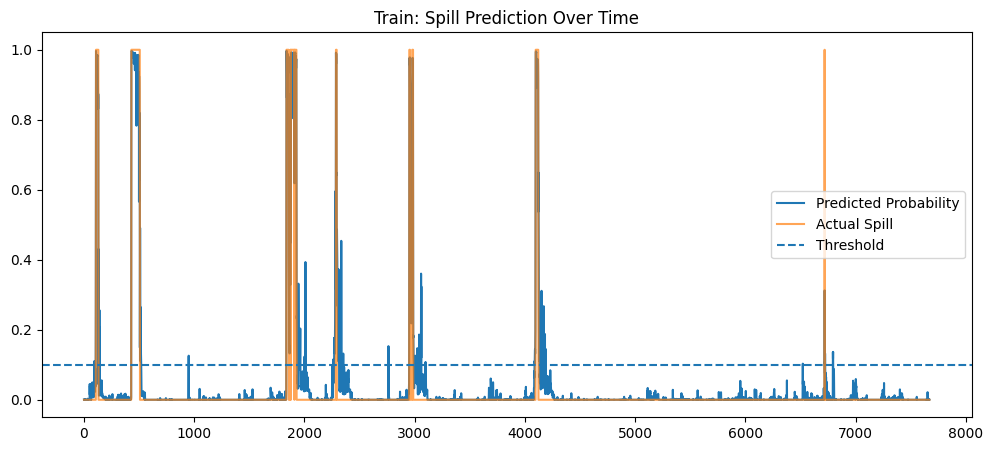

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(y_train_prob, label="Predicted Probability")
plt.plot(y_train.values, label="Actual Spill", alpha=0.7)

plt.axhline(threshold, linestyle="--", label="Threshold")

plt.legend()
plt.title("Train: Spill Prediction Over Time")
plt.show()

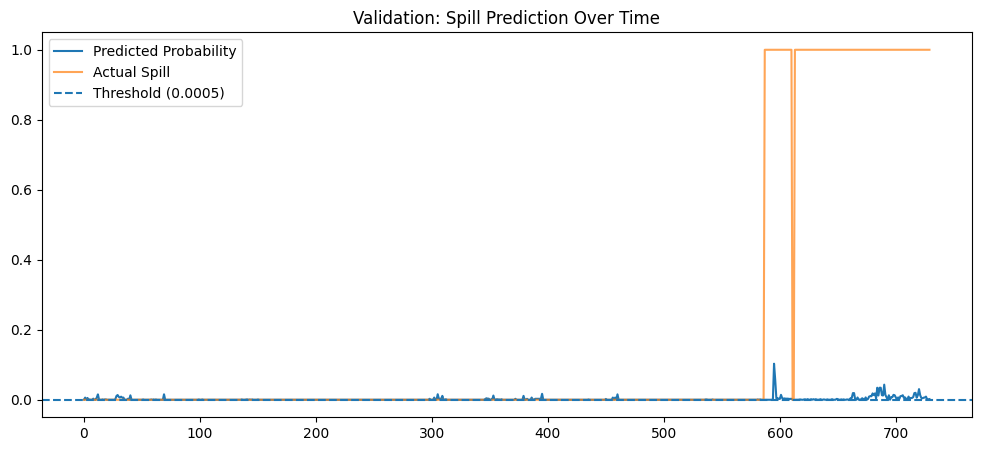

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(y_val_prob, label="Predicted Probability")
plt.plot(y_val.values, label="Actual Spill", alpha=0.7)

plt.axhline(0.0005, linestyle="--", label="Threshold (0.0005)")

plt.legend()
plt.title("Validation: Spill Prediction Over Time")
plt.show()

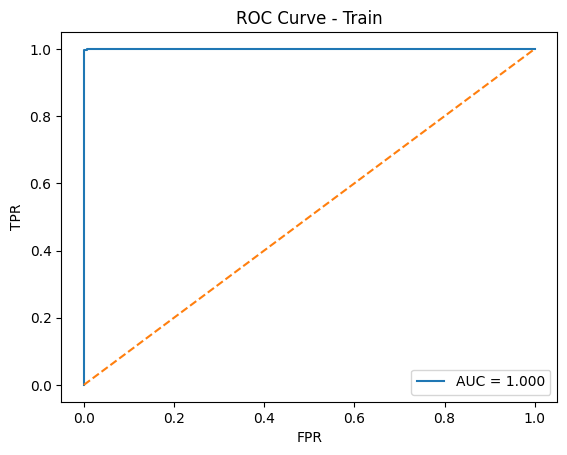

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_train, y_train_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - Train")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

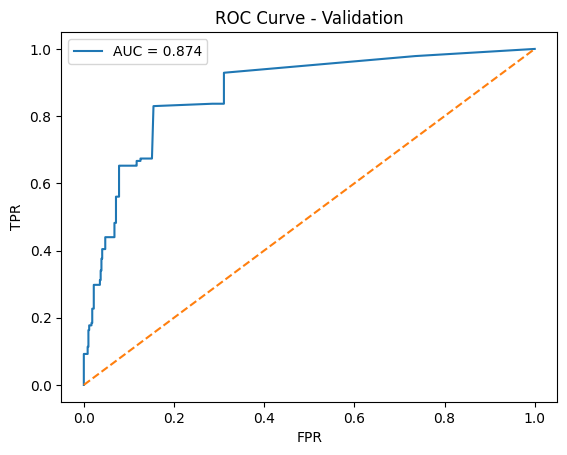

In [ ]:
fpr, tpr, _ = roc_curve(y_val, y_val_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - Validation")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

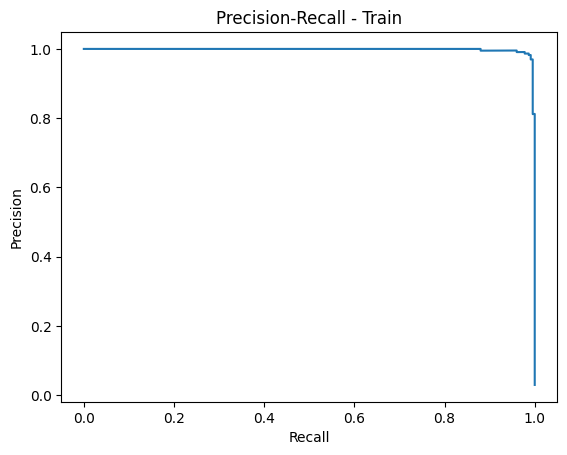

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_train, y_train_prob)

plt.figure()
plt.plot(recall, precision)
plt.title("Precision-Recall - Train")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

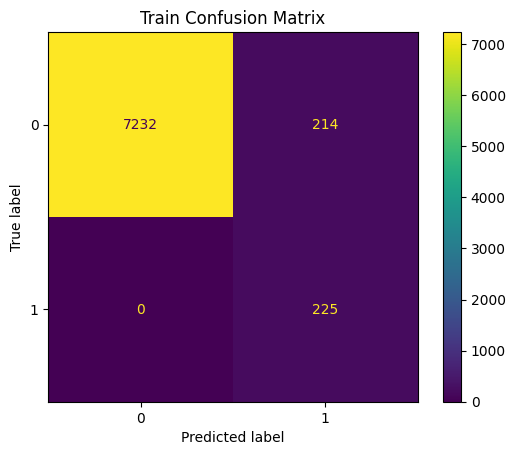

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_train_pred = (y_train_prob > threshold).astype(int)

cm = confusion_matrix(y_train, y_train_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Train Confusion Matrix")
plt.show()

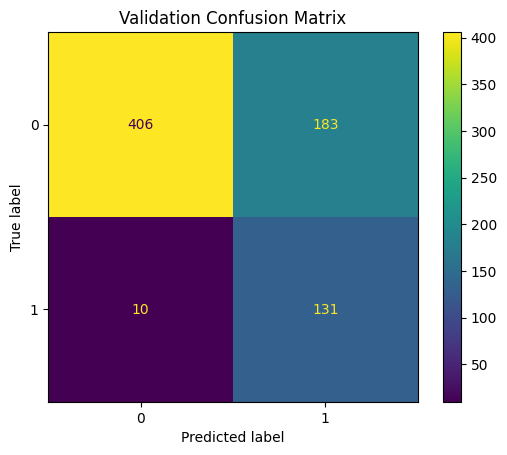

In [ ]:
y_val_pred = (y_val_prob >= 0.00005).astype(int)

cm = confusion_matrix(y_val, y_val_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Validation Confusion Matrix")
plt.show()

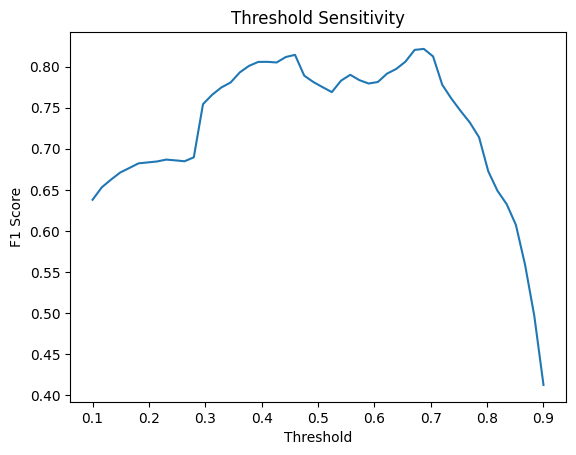

In [ ]:
from sklearn.metrics import f1_score

thresholds = np.linspace(0.1, 0.9, 50)
f1_scores = []

for t in thresholds:
    preds = (y_test_prob > t).astype(int)
    f1_scores.append(f1_score(y_test, preds))

plt.plot(thresholds, f1_scores)
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold Sensitivity")
plt.show()

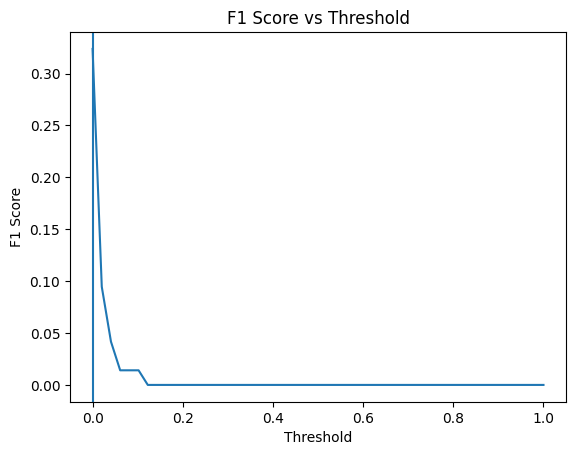

Best Threshold: 0.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

y_val_proba = model.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0, 1, 50)
f1_scores = []

for t in thresholds:
    preds = (y_val_proba >= t).astype(int)
    f1 = f1_score(y_val, preds)
    f1_scores.append(f1)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

plt.figure()
plt.plot(thresholds, f1_scores)
plt.axvline(best_threshold)
plt.title("F1 Score vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.show()

print("Best Threshold:", best_threshold)

# **Live Spill Prediction**

---



In [ ]:
# Combine API outputs into the model feature format
live_input = {
    'elevation_ft': [latest_elevation],
    'storage_af': [latest_storage],
    'inflow_cfs': [latest_inflow],
    'release_total_cfs': [latest_release_total],
    'release_outlet_cfs': [latest_release_outlet],
    'precip_in': [forecast_precip],
    'precip_lag1_in': [precip_3day],
    'imputed': [0],
    'forecast_precip': [forecast_precip],
    'precip_3day': [precip_3day],
    'precip_7day': [precip_7day]
}

# Generate Prediction
prob = model.predict_proba(live_df)[:, 1][0]
prediction = "SPILL RISK" if prob > threshold else "NO SPILL"

print("--- Live Prediction Report ---")
print(f"Current Elevation (RISE): {latest_elevation} ft")
print(f"Forecast Precip (OpenMeteo): {forecast_precip} in")
print(f"Calculated Probability: {prob:.2%}")
print(f"Status: {prediction}")

# **Assessment tool - Sliding scale predictor**

---



In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd

# Calculate dynamic ranges from the dataset
elev_min, elev_max = float(train_df['elevation_ft'].min()), float(train_df['elevation_ft'].max())
stor_min, stor_max = float(train_df['storage_af'].min()), float(train_df['storage_af'].max())
prec_min, prec_max = float(train_df['precip_in'].min()), float(train_df['precip_in'].max())
inflow_min, inflow_max = float(train_df['inflow_cfs'].min()), float(train_df['inflow_cfs'].max())
release_total_min, release_total_max = float(train_df['release_total_cfs'].min()), float(train_df['release_total_cfs'].max())
release_outlet_min, release_outlet_max = float(train_df['release_outlet_cfs'].min()), float(train_df['release_outlet_cfs'].max())

# Define UI Elements with dynamic ranges
elev_slider = widgets.FloatSlider(value=elev_min, min=elev_min, max=elev_max, step=0.1, description='Elevation (ft):')
stor_slider = widgets.FloatSlider(value=stor_min, min=stor_min, max=stor_max, step=100.0, description='Storage (af):')
prec_slider = widgets.FloatSlider(value=0.0, min=prec_min, max=prec_max, step=0.01, description='Precip (in):')
inflow_slider = widgets.FloatSlider(value=inflow_min, min=inflow_min, max=inflow_max, step=1.0, description='Inflow (cfs):')
release_total_slider = widgets.FloatSlider(value=0.0, min=0.0, max=release_total_max, step=1.0, description='Release Total (cfs):')
release_outlet_slider = widgets.FloatSlider(value=release_outlet_min, min=release_outlet_min, max=release_outlet_max, step=1.0, description='Release Outlet (cfs):')

predict_btn = widgets.Button(description="Predict Spill Risk", button_style='info')
output = widgets.Output()

def run_prediction(b):
    with output:
        clear_output()
        # Prepare feature vector based on slider values
        input_data = {
            'elevation_ft': [elev_slider.value],
            'storage_af': [stor_slider.value],
            'inflow_cfs': [inflow_slider.value],
            'release_total_cfs': [release_total_slider.value],
            'release_outlet_cfs': [release_outlet_slider.value],
            'precip_in': [prec_slider.value],
            'precip_lag1_in': [prec_slider.value],
            'imputed': [0],
            'forecast_precip': [prec_slider.value],
            'precip_3day': [prec_slider.value * 3],
            'precip_7day': [prec_slider.value * 7]
        }
        df = pd.DataFrame(input_data, columns=features)
        prob = model.predict_proba(df)[:, 1][0]
        color = "red" if prob > threshold else "green"
        print(f"Predicted Spill Probability: {prob:.2%}")
        display(widgets.HTML(f"<b style='color:{color}'>Status: {'SPILL RISK' if prob > threshold else 'SAFE'}</b>"))

predict_btn.on_click(run_prediction)
display(widgets.VBox([elev_slider, stor_slider, inflow_slider, release_total_slider, release_outlet_slider, prec_slider, predict_btn, output]))
